# Data Preparation

### Why Data Preparation Matters

Before we dive into model design, we need high-quality data.  
In this project, we aim to generate *synthetic human-like handwriting* to improve CAPTCHA robustness against bots.

Both our **Conditional GAN** and **Conditional Diffusion Model** will need:
- Clean, normalized images of handwritten digits or characters.  
- Corresponding class labels (digits 0–9) to guide the generation process.


## The MNIST Dataset

The [MNIST dataset](http://yann.lecun.com/exdb/mnist/) contains 70,000 grayscale images of handwritten digits (0–9).  
Each image is **28×28 pixels** and belongs to one of 10 classes.

For our project:
- Each digit represents a "class condition" the model should learn to generate.
- We’ll normalize all pixel values to the range `[-1, 1]` — a common practice for GANs and diffusion models.


## 1.0 Import and Setup 

In [1]:
# Import core libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os, sys

from data_utils.dataloader import get_mnist_loaders
from utils.visualize import show_batch

device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f" Running on device: {device}")


 Running on device: mps


In [2]:
# Load data using helper script 

# Define transformations: ToTensor + normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale to [-1, 1]
])

# Load using our helper function
train_loader, test_loader = get_mnist_loaders(batch_size=128, transform=transform)

print(f"Training batches: {len(train_loader)} | Test batches: {len(test_loader)}")



  0%|                                              | 0.00/9.91M [00:00<?, ?B/s]

  0%|▏                                     | 32.8k/9.91M [00:00<01:17, 127kB/s]

  1%|▍                                     | 98.3k/9.91M [00:00<00:46, 210kB/s]

  2%|▊                                      | 197k/9.91M [00:00<00:35, 271kB/s]

  4%|█▌                                     | 393k/9.91M [00:01<00:21, 441kB/s]

...

 93%|██████████████████████████████████▌  | 1.54M/1.65M [00:02<00:00, 1.18MB/s]

100%|██████████████████████████████████████| 1.65M/1.65M [00:02<00:00, 763kB/s]

  0%|                                              | 0.00/4.54k [00:00<?, ?B/s]

100%|█████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 7.75MB/s]

Training batches: 469 | Test batches: 79


At this point, we have  loaded MNIST with the correct preprocessing applied.  
Each image is now a PyTorch tensor ready for input to a neural network.

We can run some quick samples to visualize them


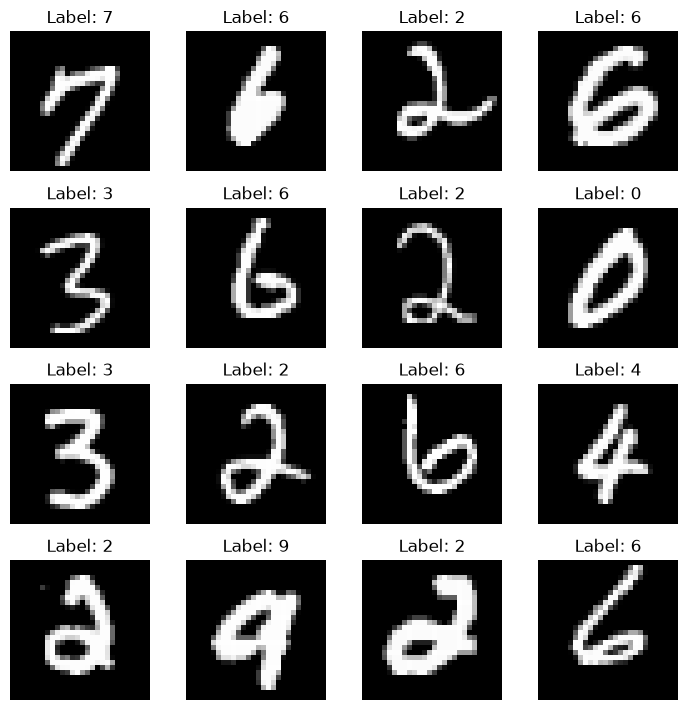

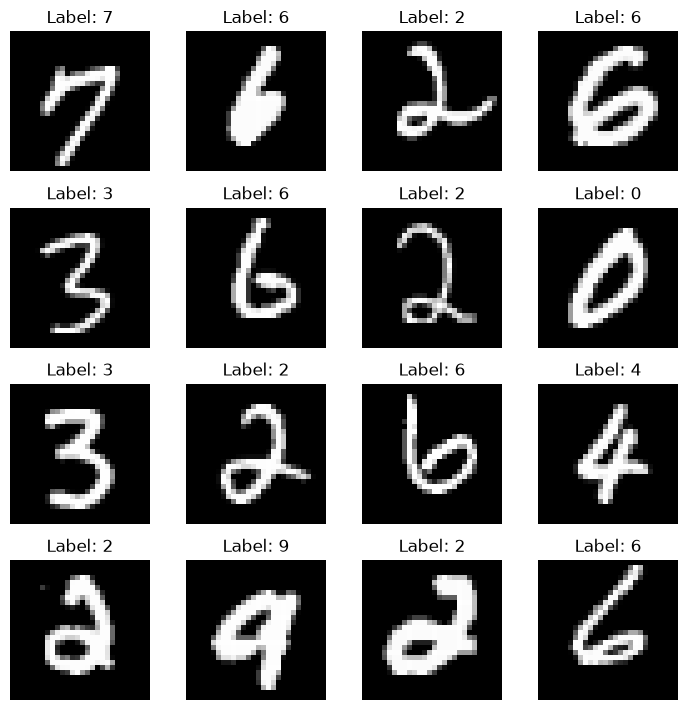

In [3]:
# visualize a batch of images 

# Grab one batch from the DataLoader
images, labels = next(iter(train_loader))

# Visualize using our utility function
show_batch(images, labels, n=16)


Each image above is a 28×28 grayscale digit from MNIST.  
Notice that the background is now dark and the digit strokes are light — this is due to our `[-1, 1]` normalization.

In the next stages:
- The **Generator** will try to create similar images from random noise and class labels.
- The **Discriminator** (and later, our **Diffusion Model**) will try to distinguish real from synthetic handwriting.

For now, let’s save a small batch of these processed images — we’ll reuse them to verify that our models are conditioning correctly.

In [4]:
# Save processed samples
os.makedirs("../data/processed", exist_ok=True)

sample_batch = {
    "images": images[:100].to(device),
    "labels": labels[:100].to(device)
}

torch.save(sample_batch, "../data/processed/sample_batch.pt")
print("Saved 100 sample images to /data/processed/sample_batch.pt")

Saved 100 sample images to /data/processed/sample_batch.pt
